# New-models benchmark plots

Reads the latest `logs/new_models_qubo_*.json` (sparsity generator) **or**
`logs/new_models_geo_qubo_*.json` (geometric/knn generator) produced by the
corresponding Segment 2 script and renders five heatmap figures — one per
metric — comparing the **hybrid** and **alex** formulations side-by-side.

| Figure | Metric |
|--------|--------|
| 1 | Success rate — P(finding optimum in 1 000 reads) |
| 2 | Mean first-hit reads (solved instances only) |
| 3 | Mean approximation ratio = best\_cost / opt |
| 4 | Feasible-read rate — fraction of 1 000 reads that form a valid Steiner tree |
| 5 | Mean time-to-solution (seconds) |

Each figure has **rows = models** × **columns = density parameter** (edge
probability *p* for sparsity, *k*-nearest-neighbours for geometric).  The
heatmap cell axes are **x = number of nodes** and **y = number of terminals**.

In [1]:
import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# ── File selection ───────────────────────────────────────────────────────────
# Set QUBO_JSON_PATH to an explicit path to override auto-detection.
# Leave as None to load the most recent matching file from LOGS_DIR.
# For the geometric benchmark set GEO = True (or just point at the file).
QUBO_JSON_PATH = "/Users/daghanerdonmez/Desktop/benchmark/logs/new_models_qubo_20260508_172220.json"
GEO = False          # True  -> look for new_models_geo_qubo_*.json
                     # False -> look for new_models_qubo_*.json

LOGS_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "benchmark", "logs",
)

def load_results(path=None, geo=False, directory=LOGS_DIR):
    if path is None:
        pattern = "new_models_geo_qubo_*.json" if geo else "new_models_qubo_*.json"
        files = sorted(glob.glob(os.path.join(directory, pattern)))
        if not files:
            raise FileNotFoundError(
                f"No {pattern} found in {directory}. Run the segment-2 benchmark first."
            )
        path = files[-1]
    with open(path) as f:
        return json.load(f), path

data, data_path = load_results(QUBO_JSON_PATH, geo=GEO)
meta      = data["_meta"]
instances = data["instances"]

# ── Detect density axis ──────────────────────────────────────────────────────
if "edge_probability_list" in meta:
    density_list  = meta["edge_probability_list"]
    density_label = "p"
    density_key   = "edge_probability"
elif "k_neighbors_list" in meta:
    density_list  = meta["k_neighbors_list"]
    density_label = "knn"
    density_key   = "k_neighbors"
else:
    raise ValueError("Cannot determine density axis from meta keys.")

n_list     = meta["node_count_list"]
k_list     = meta["terminal_count_list"]
model_list = meta["models"]            # e.g. ["hybrid", "alex"]
budget     = meta["total_reads_budget"]

print(f"File        : {data_path}")
print(f"Density axis: {density_label} = {density_list}")
print(f"n values    : {n_list}")
print(f"k values    : {k_list}")
print(f"Models      : {model_list}")
print(f"Instances   : {len(instances)}")
print(f"Read budget : {budget} ({meta['num_trials']} × {meta['num_reads_per_trial']})")

File        : /Users/daghanerdonmez/Desktop/benchmark/logs/new_models_qubo_20260508_172220.json
Density axis: p = [0.1, 0.3, 0.6]
n values    : [4, 6, 8, 10, 12]
k values    : [2, 3, 4, 5, 6]
Models      : ['hybrid', 'alex']
Instances   : 690
Read budget : 1000 (10 × 100)


In [3]:
# ── Build (model, density, k, n) arrays for every metric ────────────────────
# We aggregate directly from instances so this works even if the benchmark
# was interrupted before the summary section was written.

shape = (len(model_list), len(density_list), len(k_list), len(n_list))

_solved_sum   = np.zeros(shape)
_first_sum    = np.zeros(shape)
_first_cnt    = np.zeros(shape, dtype=int)   # only solved instances
_ratio_sum    = np.zeros(shape)
_feasib_sum   = np.zeros(shape)
_tts_sum      = np.zeros(shape)
_cnt          = np.zeros(shape, dtype=int)

for inst in instances.values():
    d_val = inst.get(density_key)
    n_    = inst.get("node_count")
    k_    = inst.get("terminal_count")
    if d_val not in density_list or n_ not in n_list or k_ not in k_list:
        continue
    di = density_list.index(d_val)
    ni = n_list.index(n_)
    ki = k_list.index(k_)

    for mi, model in enumerate(model_list):
        m = inst.get("models", {}).get(model)
        if m is None:
            continue
        _cnt[mi, di, ki, ni] += 1
        _solved_sum[mi, di, ki, ni]  += int(m.get("solved", False))
        _feasib_sum[mi, di, ki, ni]  += m.get("feasible_read_rate", 0.0)
        _tts_sum[mi, di, ki, ni]     += m.get("time_to_solution", 0.0)
        ratio = m.get("approx_ratio")
        if ratio is not None:
            _ratio_sum[mi, di, ki, ni] += ratio
        if m.get("solved") and m.get("first_hit_reads") is not None:
            _first_sum[mi, di, ki, ni] += m["first_hit_reads"]
            _first_cnt[mi, di, ki, ni] += 1

def _safe_div(num, den, fill=np.nan):
    out = np.full(num.shape, fill)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

arr_success = _safe_div(_solved_sum, _cnt)
arr_first   = _safe_div(_first_sum,  _first_cnt)    # NaN where nothing solved
arr_ratio   = _safe_div(_ratio_sum,  _cnt)
arr_feasib  = _safe_div(_feasib_sum, _cnt)
arr_tts     = _safe_div(_tts_sum,    _cnt)

# Cells where k > n are structurally invalid — force NaN.
for ki, k in enumerate(k_list):
    for ni, n in enumerate(n_list):
        if k > n:
            arr_success[:, :, ki, ni] = np.nan
            arr_first  [:, :, ki, ni] = np.nan
            arr_ratio  [:, :, ki, ni] = np.nan
            arr_feasib [:, :, ki, ni] = np.nan
            arr_tts    [:, :, ki, ni] = np.nan

print("Array shape (model, density, k, n):", arr_success.shape)

Array shape (model, density, k, n): (2, 3, 5, 5)


In [4]:
def plot_metric(
    arr, *,
    title, cbar_label, fmt, cmap,
    vmin, vmax,
    model_list, density_list, n_list, k_list,
    density_label,
    missing_glyph="—",
):
    """
    arr shape: (n_models, n_density, n_k, n_n)

    Renders a grid of heatmaps:
        rows  = models
        cols  = density values
    Each cell: y-axis = k (terminals), x-axis = n (nodes).
    """
    n_rows = len(model_list)
    n_cols = len(density_list)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 4.0 * n_rows),
        squeeze=False,
    )

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#dddddd")
    mid = 0.5 * (vmin + vmax)

    for mi, model in enumerate(model_list):
        for di, d_val in enumerate(density_list):
            ax = axes[mi][di]
            masked = np.ma.masked_invalid(arr[mi, di])
            im = ax.imshow(
                masked, origin="lower", aspect="auto",
                cmap=cmap_obj, vmin=vmin, vmax=vmax,
            )
            ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
            ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
            ax.set_xlabel("nodes (n)")
            ax.set_ylabel("terminals (k)")
            ax.set_title(f"{model}  |  {density_label} = {d_val}")

            for ki in range(len(k_list)):
                for ni in range(len(n_list)):
                    v = arr[mi, di, ki, ni]
                    if np.isnan(v):
                        txt   = missing_glyph
                        color = "#888888"
                    else:
                        txt   = fmt.format(v)
                        color = "white" if v < mid else "black"
                    ax.text(ni, ki, txt, ha="center", va="center",
                            color=color, fontsize=8)

            plt.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    return fig

## 1 · Success rate
Fraction of instances (across seeds) where the QUBO solver found the optimal
cost within the full read budget.

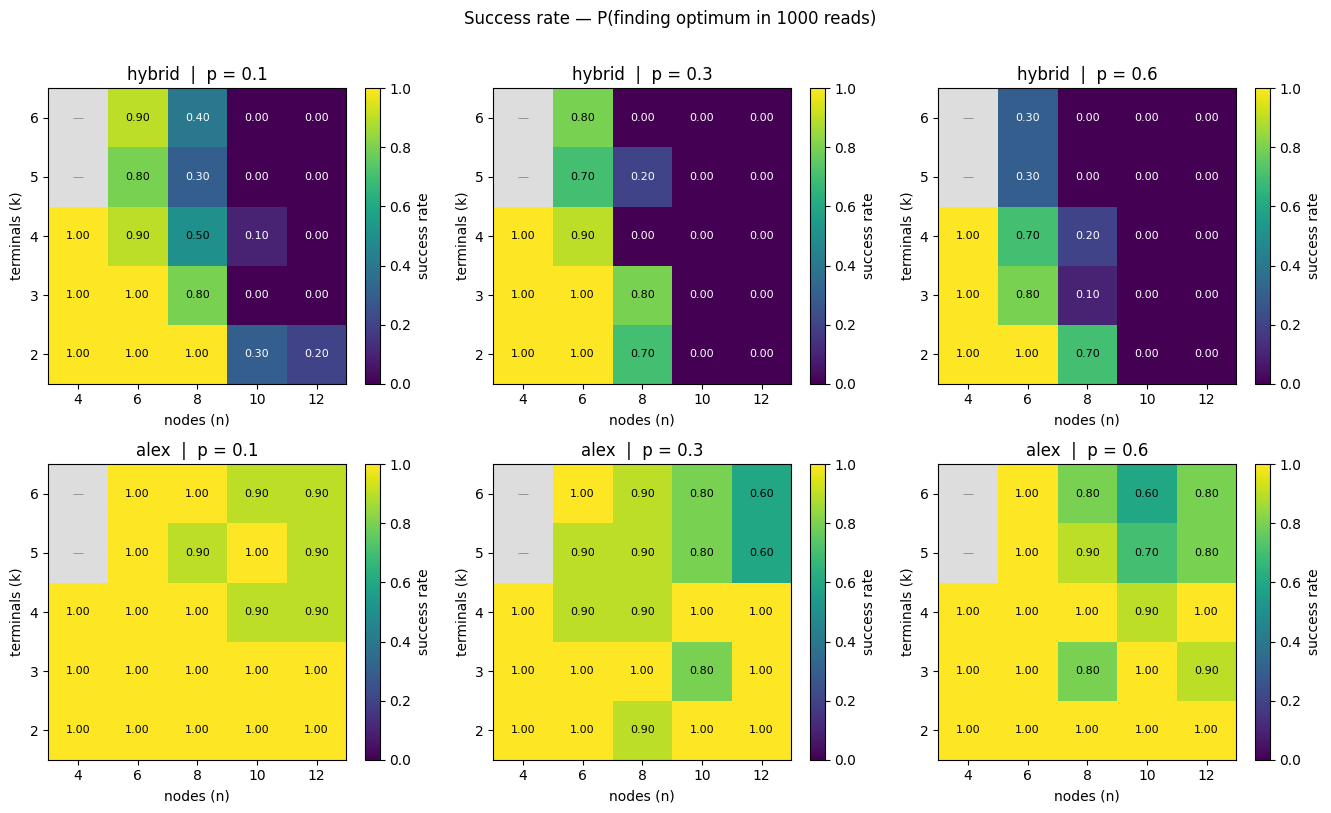

In [5]:
fig1 = plot_metric(
    arr_success,
    title=f"Success rate — P(finding optimum in {budget} reads)",
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0, vmax=1.0,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 2 · Mean first-hit reads
Among instances that were solved, the average number of reads needed before
the optimal cost was first reached.  Grey cells mean no instance in that cell
was solved.

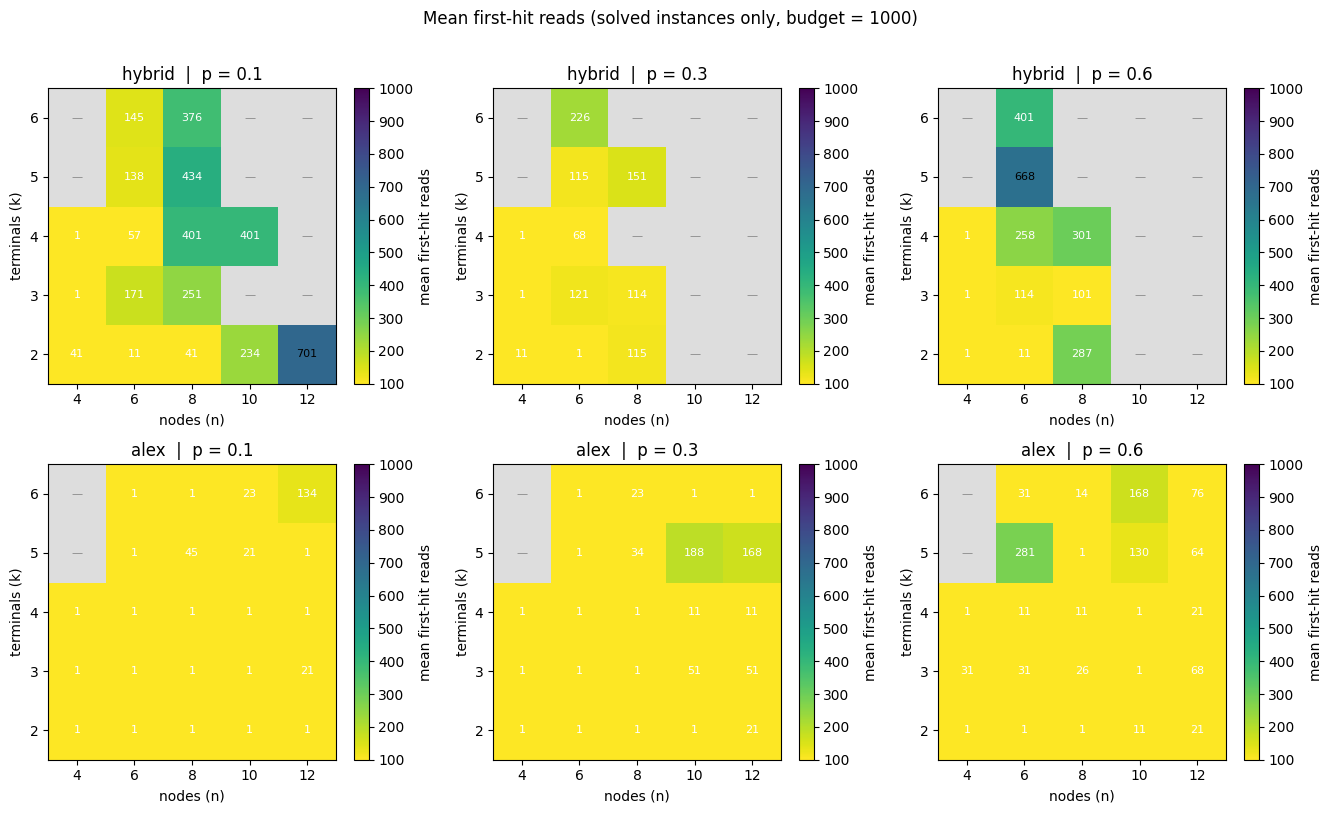

In [6]:
reads_per_trial = meta["num_reads_per_trial"]

fig2 = plot_metric(
    arr_first,
    title=f"Mean first-hit reads (solved instances only, budget = {budget})",
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",      # fewer reads = brighter = better
    vmin=reads_per_trial, vmax=budget,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 3 · Mean approximation ratio
`best_cost_found / opt_cost` averaged across all instances.  A value of 1.00
means the solver always matched the ILP optimum; higher values indicate it
settled for a suboptimal solution.

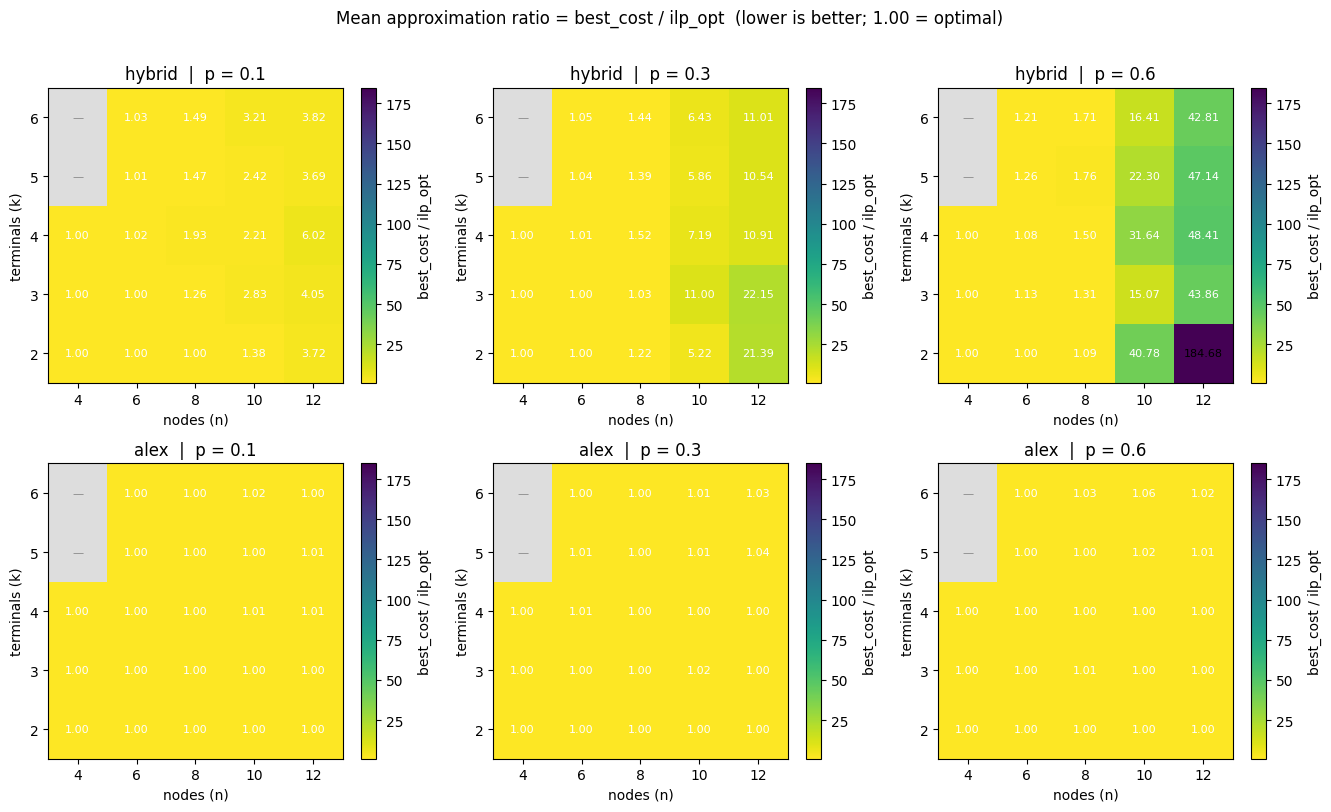

In [7]:
finite_ratio = arr_ratio[np.isfinite(arr_ratio)]
vmax_ratio   = max(1.05, float(np.nanmax(arr_ratio))) if finite_ratio.size else 1.05

fig3 = plot_metric(
    arr_ratio,
    title="Mean approximation ratio = best_cost / ilp_opt  (lower is better; 1.00 = optimal)",
    cbar_label="best_cost / ilp_opt",
    fmt="{:.2f}",
    cmap="viridis_r",      # closer to 1 = brighter = better
    vmin=1.0, vmax=vmax_ratio,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 4 · Feasible-read rate
Fraction of the 1 000 individual reads (not just the best) that decode to a
valid Steiner tree (connected, acyclic, spanning all terminals), averaged
across instances.

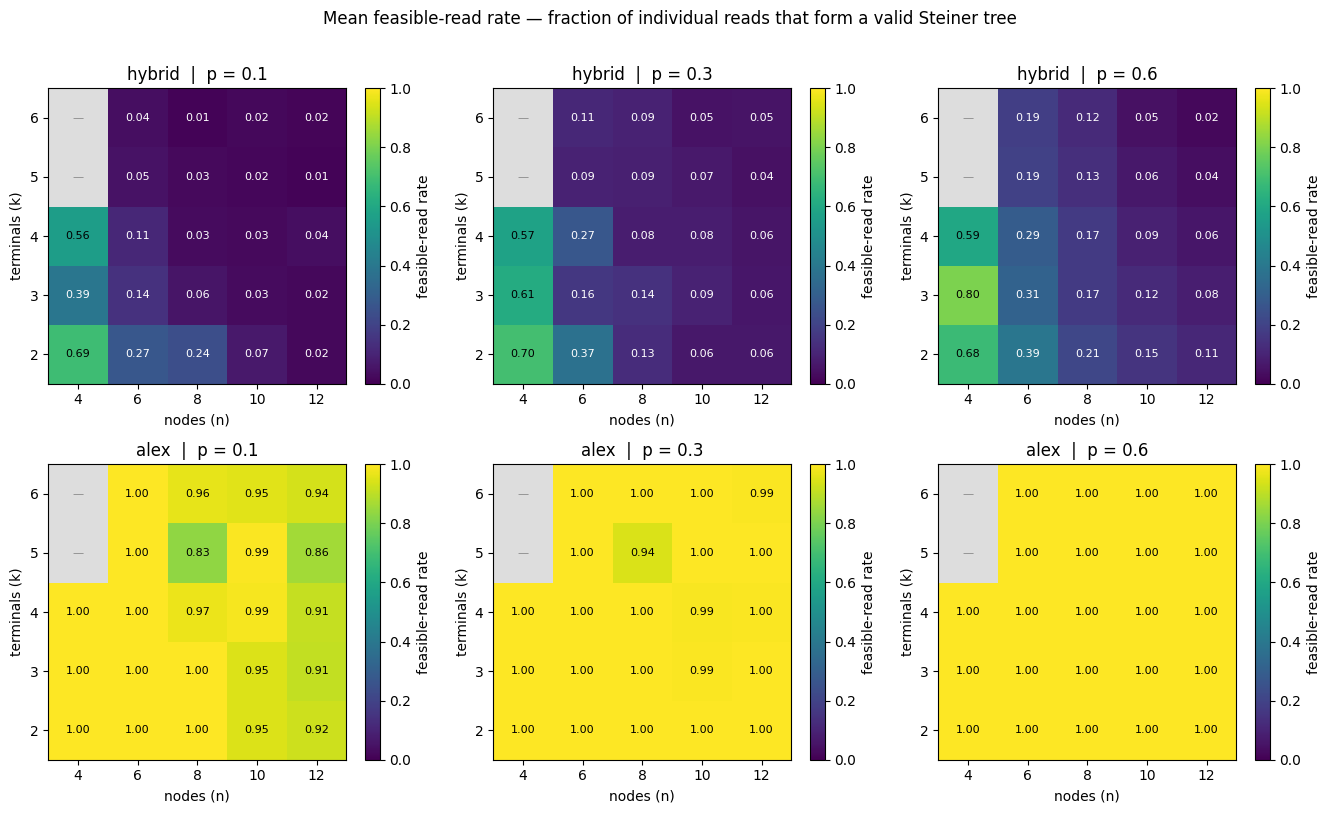

In [8]:
fig4 = plot_metric(
    arr_feasib,
    title="Mean feasible-read rate — fraction of individual reads that form a valid Steiner tree",
    cbar_label="feasible-read rate",
    fmt="{:.2f}",
    cmap="viridis",        # higher = brighter = better
    vmin=0.0, vmax=1.0,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 5 · Mean time to solution
Wall-clock seconds until the optimal cost was first found.  For unsolved
instances this is the total elapsed time for the full read budget.

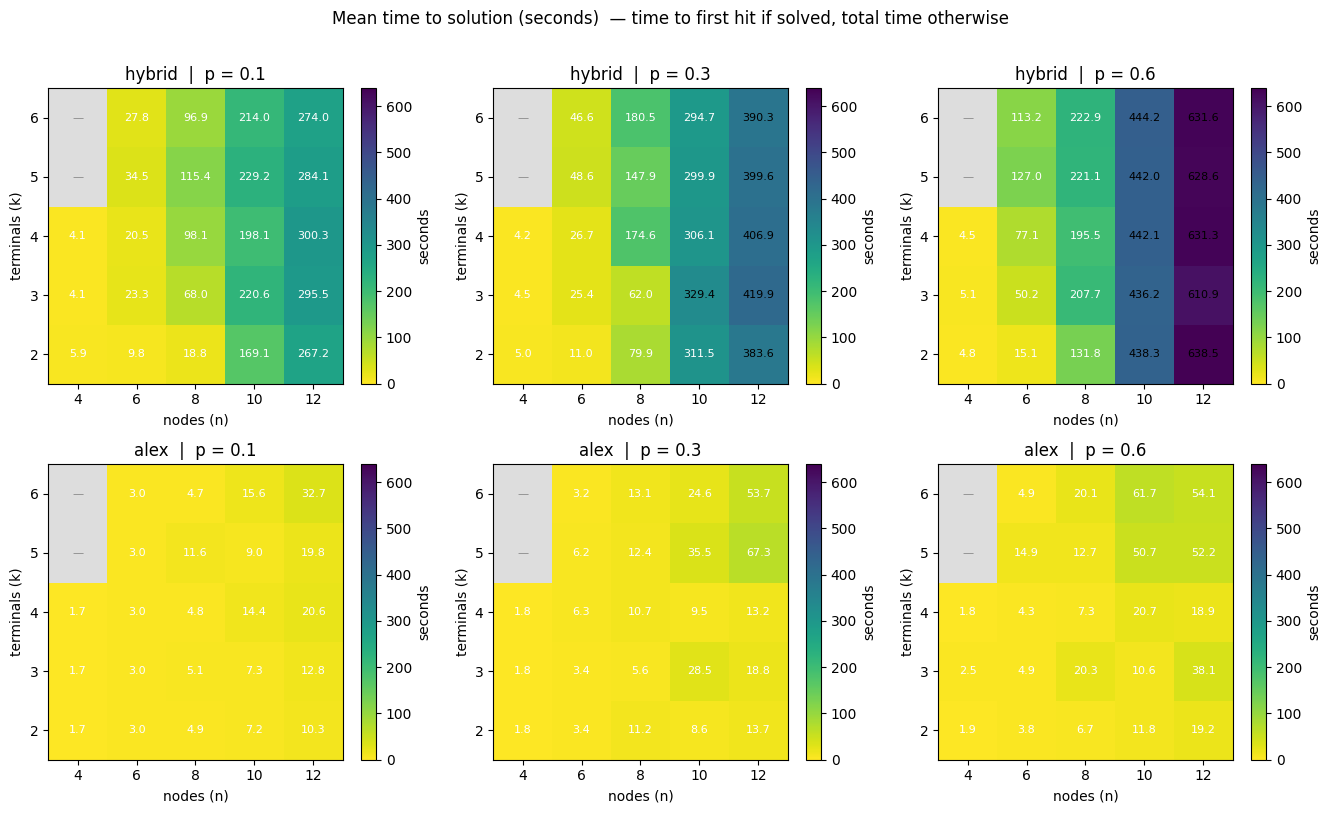

In [9]:
finite_tts = arr_tts[np.isfinite(arr_tts)]
vmax_tts   = float(np.nanmax(arr_tts)) if finite_tts.size else 1.0

fig5 = plot_metric(
    arr_tts,
    title="Mean time to solution (seconds)  — time to first hit if solved, total time otherwise",
    cbar_label="seconds",
    fmt="{:.1f}",
    cmap="viridis_r",      # less time = brighter = better
    vmin=0.0, vmax=vmax_tts,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 6 · Head-to-head difference maps  (hybrid − alex)
Positive = hybrid is better, negative = alex is better.  Uses the same
per-combo averages already computed above.

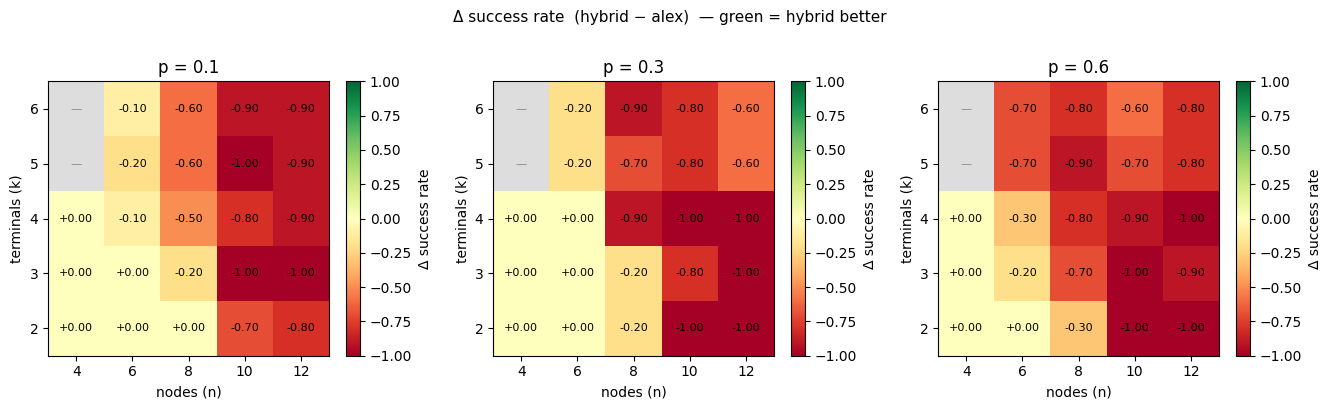

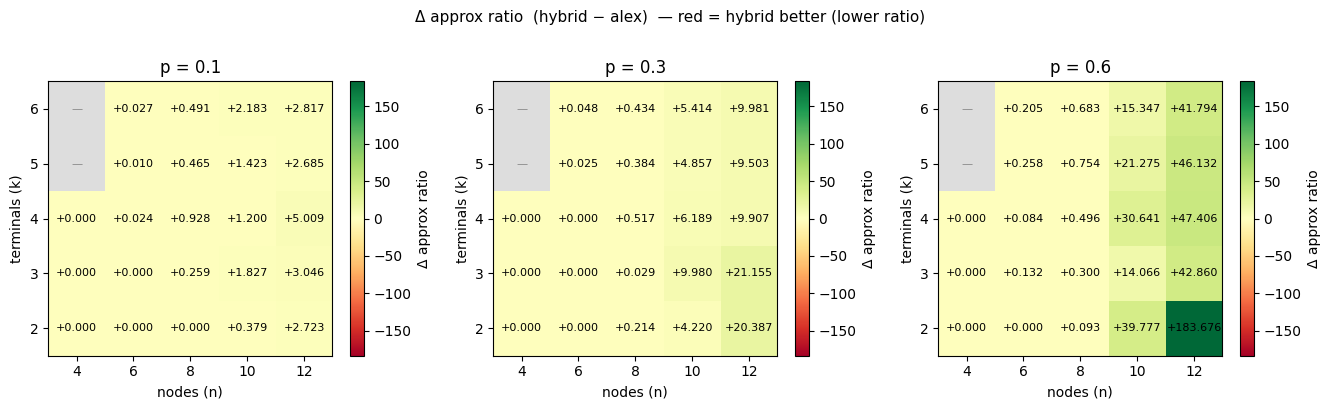

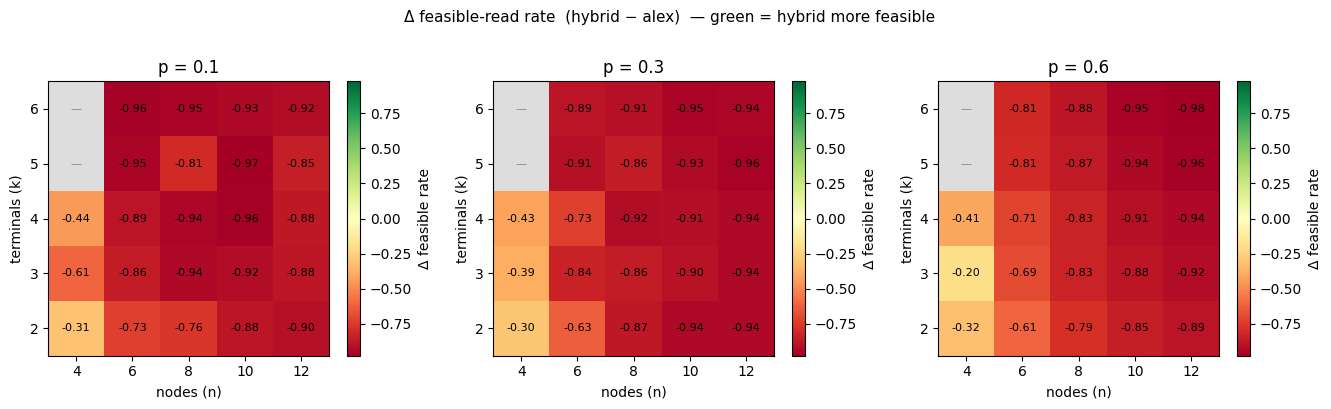

In [10]:
if len(model_list) == 2 and "hybrid" in model_list and "alex" in model_list:
    hi = model_list.index("hybrid")
    ai = model_list.index("alex")

    def _diff_heatmaps(arr_a, arr_b, *, title, cbar_label, fmt):
        """Plot (arr_a - arr_b) per density value."""
        diff = arr_a - arr_b          # shape (density, k, n)
        n_cols = len(density_list)
        fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.0), squeeze=False)
        vext = np.nanmax(np.abs(diff))
        if vext == 0 or np.isnan(vext):
            vext = 1e-3
        cmap_obj = plt.get_cmap("RdYlGn").copy()
        cmap_obj.set_bad(color="#dddddd")
        for di, d_val in enumerate(density_list):
            ax = axes[0][di]
            masked = np.ma.masked_invalid(diff[di])
            im = ax.imshow(masked, origin="lower", aspect="auto",
                           cmap=cmap_obj, vmin=-vext, vmax=vext)
            ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
            ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
            ax.set_xlabel("nodes (n)")
            ax.set_ylabel("terminals (k)")
            ax.set_title(f"{density_label} = {d_val}")
            for ki in range(len(k_list)):
                for ni in range(len(n_list)):
                    v = diff[di, ki, ni]
                    txt   = "—" if np.isnan(v) else fmt.format(v)
                    color = "#888888" if np.isnan(v) else "black"
                    ax.text(ni, ki, txt, ha="center", va="center",
                            color=color, fontsize=8)
            plt.colorbar(im, ax=ax, label=cbar_label)
        fig.suptitle(title, fontsize=11, y=1.01)
        fig.tight_layout()
        return fig

    # Success rate: positive = hybrid wins
    _diff_heatmaps(
        arr_success[hi], arr_success[ai],
        title="Δ success rate  (hybrid − alex)  — green = hybrid better",
        cbar_label="Δ success rate", fmt="{:+.2f}",
    )
    plt.show()

    # Approximation ratio: negative = hybrid wins (lower ratio is better)
    _diff_heatmaps(
        arr_ratio[hi], arr_ratio[ai],
        title="Δ approx ratio  (hybrid − alex)  — red = hybrid better (lower ratio)",
        cbar_label="Δ approx ratio", fmt="{:+.3f}",
    )
    plt.show()

    # Feasible-read rate: positive = hybrid wins
    _diff_heatmaps(
        arr_feasib[hi], arr_feasib[ai],
        title="Δ feasible-read rate  (hybrid − alex)  — green = hybrid more feasible",
        cbar_label="Δ feasible rate", fmt="{:+.2f}",
    )
    plt.show()
else:
    print("Diff maps require exactly the 'hybrid' and 'alex' models — skipping.")

# GEO

# New-models benchmark plots

Reads the latest `logs/new_models_qubo_*.json` (sparsity generator) **or**
`logs/new_models_geo_qubo_*.json` (geometric/knn generator) produced by the
corresponding Segment 2 script and renders five heatmap figures — one per
metric — comparing the **hybrid** and **alex** formulations side-by-side.

| Figure | Metric |
|--------|--------|
| 1 | Success rate — P(finding optimum in 1 000 reads) |
| 2 | Mean first-hit reads (solved instances only) |
| 3 | Mean approximation ratio = best\_cost / opt |
| 4 | Feasible-read rate — fraction of 1 000 reads that form a valid Steiner tree |
| 5 | Mean time-to-solution (seconds) |

Each figure has **rows = models** × **columns = density parameter** (edge
probability *p* for sparsity, *k*-nearest-neighbours for geometric).  The
heatmap cell axes are **x = number of nodes** and **y = number of terminals**.

In [11]:
import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [12]:
# ── File selection ───────────────────────────────────────────────────────────
# Set QUBO_JSON_PATH to an explicit path to override auto-detection.
# Leave as None to load the most recent matching file from LOGS_DIR.
# For the geometric benchmark set GEO = True (or just point at the file).
QUBO_JSON_PATH = "/Users/daghanerdonmez/Desktop/benchmark/logs/new_models_geo_qubo_20260509_010011.json"
GEO = False          # True  -> look for new_models_geo_qubo_*.json
                     # False -> look for new_models_qubo_*.json

LOGS_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "benchmark", "logs",
)

def load_results(path=None, geo=False, directory=LOGS_DIR):
    if path is None:
        pattern = "new_models_geo_qubo_*.json" if geo else "new_models_qubo_*.json"
        files = sorted(glob.glob(os.path.join(directory, pattern)))
        if not files:
            raise FileNotFoundError(
                f"No {pattern} found in {directory}. Run the segment-2 benchmark first."
            )
        path = files[-1]
    with open(path) as f:
        return json.load(f), path

data, data_path = load_results(QUBO_JSON_PATH, geo=GEO)
meta      = data["_meta"]
instances = data["instances"]

# ── Detect density axis ──────────────────────────────────────────────────────
if "edge_probability_list" in meta:
    density_list  = meta["edge_probability_list"]
    density_label = "p"
    density_key   = "edge_probability"
elif "k_neighbors_list" in meta:
    density_list  = meta["k_neighbors_list"]
    density_label = "knn"
    density_key   = "k_neighbors"
else:
    raise ValueError("Cannot determine density axis from meta keys.")

n_list     = meta["node_count_list"]
k_list     = meta["terminal_count_list"]
model_list = meta["models"]            # e.g. ["hybrid", "alex"]
budget     = meta["total_reads_budget"]

print(f"File        : {data_path}")
print(f"Density axis: {density_label} = {density_list}")
print(f"n values    : {n_list}")
print(f"k values    : {k_list}")
print(f"Models      : {model_list}")
print(f"Instances   : {len(instances)}")
print(f"Read budget : {budget} ({meta['num_trials']} × {meta['num_reads_per_trial']})")

File        : /Users/daghanerdonmez/Desktop/benchmark/logs/new_models_geo_qubo_20260509_010011.json
Density axis: knn = [3, 5, 8]
n values    : [4, 6, 8, 10, 12]
k values    : [2, 3, 4, 5, 6]
Models      : ['hybrid', 'alex']
Instances   : 690
Read budget : 1000 (10 × 100)


In [13]:
# ── Build (model, density, k, n) arrays for every metric ────────────────────
# We aggregate directly from instances so this works even if the benchmark
# was interrupted before the summary section was written.

shape = (len(model_list), len(density_list), len(k_list), len(n_list))

_solved_sum   = np.zeros(shape)
_first_sum    = np.zeros(shape)
_first_cnt    = np.zeros(shape, dtype=int)   # only solved instances
_ratio_sum    = np.zeros(shape)
_feasib_sum   = np.zeros(shape)
_tts_sum      = np.zeros(shape)
_cnt          = np.zeros(shape, dtype=int)

for inst in instances.values():
    d_val = inst.get(density_key)
    n_    = inst.get("node_count")
    k_    = inst.get("terminal_count")
    if d_val not in density_list or n_ not in n_list or k_ not in k_list:
        continue
    di = density_list.index(d_val)
    ni = n_list.index(n_)
    ki = k_list.index(k_)

    for mi, model in enumerate(model_list):
        m = inst.get("models", {}).get(model)
        if m is None:
            continue
        _cnt[mi, di, ki, ni] += 1
        _solved_sum[mi, di, ki, ni]  += int(m.get("solved", False))
        _feasib_sum[mi, di, ki, ni]  += m.get("feasible_read_rate", 0.0)
        _tts_sum[mi, di, ki, ni]     += m.get("time_to_solution", 0.0)
        ratio = m.get("approx_ratio")
        if ratio is not None:
            _ratio_sum[mi, di, ki, ni] += ratio
        if m.get("solved") and m.get("first_hit_reads") is not None:
            _first_sum[mi, di, ki, ni] += m["first_hit_reads"]
            _first_cnt[mi, di, ki, ni] += 1

def _safe_div(num, den, fill=np.nan):
    out = np.full(num.shape, fill)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

arr_success = _safe_div(_solved_sum, _cnt)
arr_first   = _safe_div(_first_sum,  _first_cnt)    # NaN where nothing solved
arr_ratio   = _safe_div(_ratio_sum,  _cnt)
arr_feasib  = _safe_div(_feasib_sum, _cnt)
arr_tts     = _safe_div(_tts_sum,    _cnt)

# Cells where k > n are structurally invalid — force NaN.
for ki, k in enumerate(k_list):
    for ni, n in enumerate(n_list):
        if k > n:
            arr_success[:, :, ki, ni] = np.nan
            arr_first  [:, :, ki, ni] = np.nan
            arr_ratio  [:, :, ki, ni] = np.nan
            arr_feasib [:, :, ki, ni] = np.nan
            arr_tts    [:, :, ki, ni] = np.nan

print("Array shape (model, density, k, n):", arr_success.shape)

Array shape (model, density, k, n): (2, 3, 5, 5)


In [14]:
def plot_metric(
    arr, *,
    title, cbar_label, fmt, cmap,
    vmin, vmax,
    model_list, density_list, n_list, k_list,
    density_label,
    missing_glyph="—",
):
    """
    arr shape: (n_models, n_density, n_k, n_n)

    Renders a grid of heatmaps:
        rows  = models
        cols  = density values
    Each cell: y-axis = k (terminals), x-axis = n (nodes).
    """
    n_rows = len(model_list)
    n_cols = len(density_list)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 4.0 * n_rows),
        squeeze=False,
    )

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#dddddd")
    mid = 0.5 * (vmin + vmax)

    for mi, model in enumerate(model_list):
        for di, d_val in enumerate(density_list):
            ax = axes[mi][di]
            masked = np.ma.masked_invalid(arr[mi, di])
            im = ax.imshow(
                masked, origin="lower", aspect="auto",
                cmap=cmap_obj, vmin=vmin, vmax=vmax,
            )
            ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
            ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
            ax.set_xlabel("nodes (n)")
            ax.set_ylabel("terminals (k)")
            ax.set_title(f"{model}  |  {density_label} = {d_val}")

            for ki in range(len(k_list)):
                for ni in range(len(n_list)):
                    v = arr[mi, di, ki, ni]
                    if np.isnan(v):
                        txt   = missing_glyph
                        color = "#888888"
                    else:
                        txt   = fmt.format(v)
                        color = "white" if v < mid else "black"
                    ax.text(ni, ki, txt, ha="center", va="center",
                            color=color, fontsize=8)

            plt.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    return fig

## 1 · Success rate
Fraction of instances (across seeds) where the QUBO solver found the optimal
cost within the full read budget.

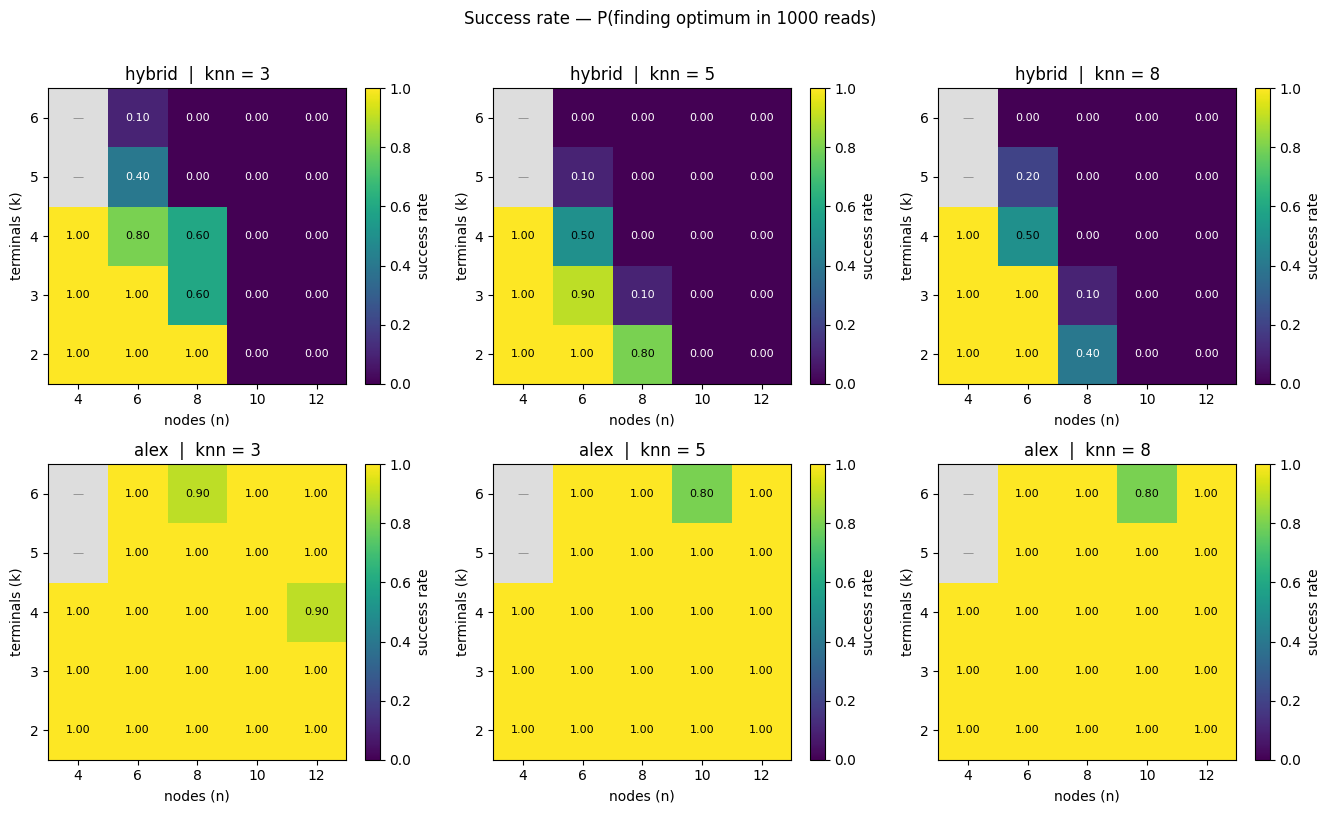

In [15]:
fig1 = plot_metric(
    arr_success,
    title=f"Success rate — P(finding optimum in {budget} reads)",
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0, vmax=1.0,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 2 · Mean first-hit reads
Among instances that were solved, the average number of reads needed before
the optimal cost was first reached.  Grey cells mean no instance in that cell
was solved.

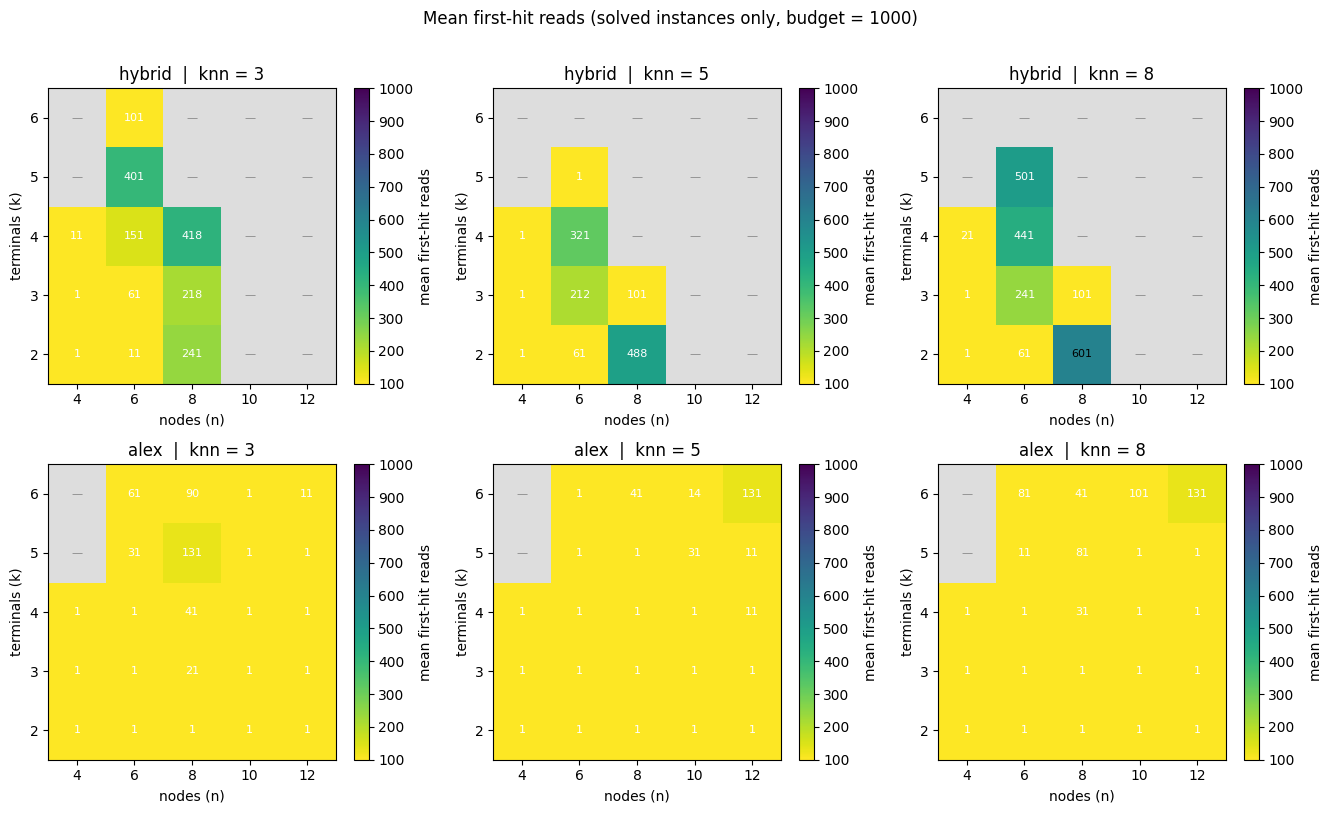

In [16]:
reads_per_trial = meta["num_reads_per_trial"]

fig2 = plot_metric(
    arr_first,
    title=f"Mean first-hit reads (solved instances only, budget = {budget})",
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",      # fewer reads = brighter = better
    vmin=reads_per_trial, vmax=budget,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 3 · Mean approximation ratio
`best_cost_found / opt_cost` averaged across all instances.  A value of 1.00
means the solver always matched the ILP optimum; higher values indicate it
settled for a suboptimal solution.

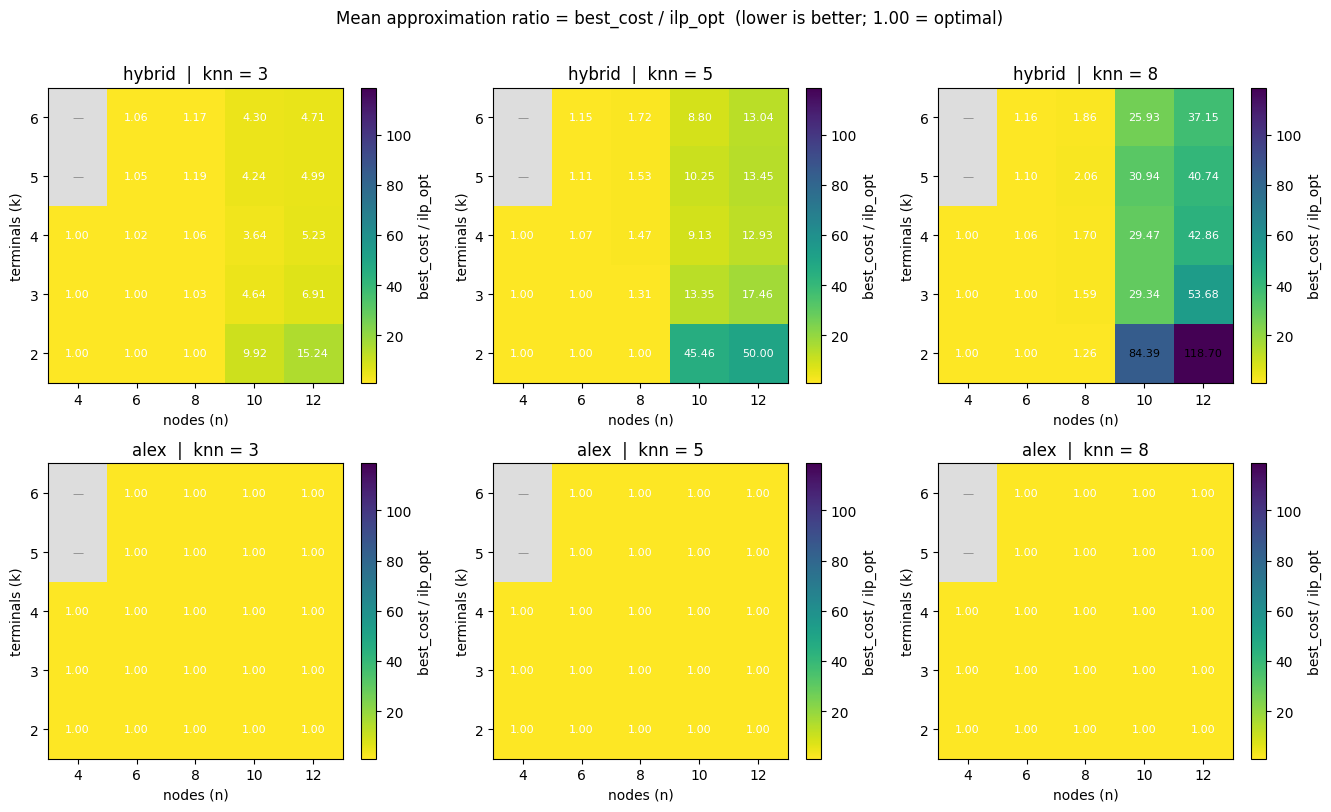

In [17]:
finite_ratio = arr_ratio[np.isfinite(arr_ratio)]
vmax_ratio   = max(1.05, float(np.nanmax(arr_ratio))) if finite_ratio.size else 1.05

fig3 = plot_metric(
    arr_ratio,
    title="Mean approximation ratio = best_cost / ilp_opt  (lower is better; 1.00 = optimal)",
    cbar_label="best_cost / ilp_opt",
    fmt="{:.2f}",
    cmap="viridis_r",      # closer to 1 = brighter = better
    vmin=1.0, vmax=vmax_ratio,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 4 · Feasible-read rate
Fraction of the 1 000 individual reads (not just the best) that decode to a
valid Steiner tree (connected, acyclic, spanning all terminals), averaged
across instances.

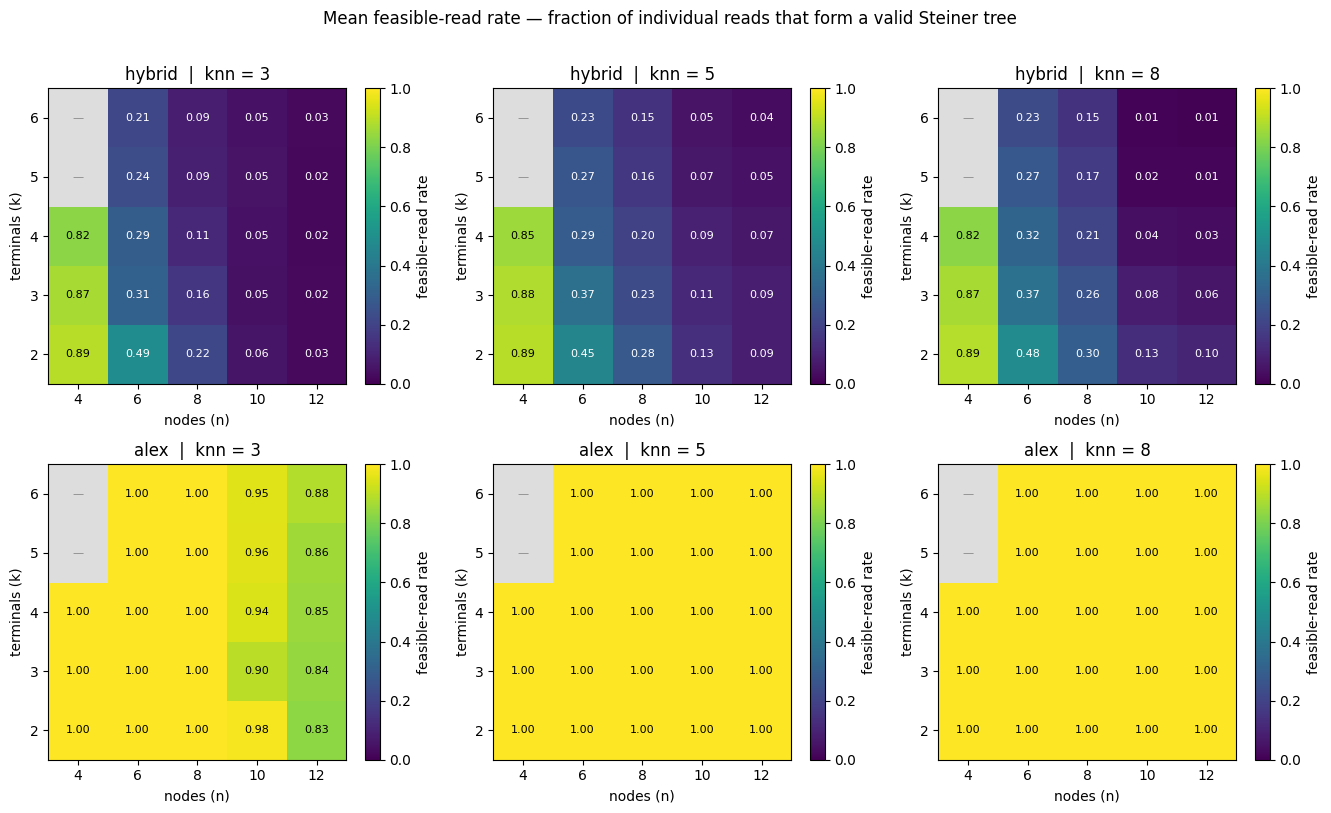

In [18]:
fig4 = plot_metric(
    arr_feasib,
    title="Mean feasible-read rate — fraction of individual reads that form a valid Steiner tree",
    cbar_label="feasible-read rate",
    fmt="{:.2f}",
    cmap="viridis",        # higher = brighter = better
    vmin=0.0, vmax=1.0,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 5 · Mean time to solution
Wall-clock seconds until the optimal cost was first found.  For unsolved
instances this is the total elapsed time for the full read budget.

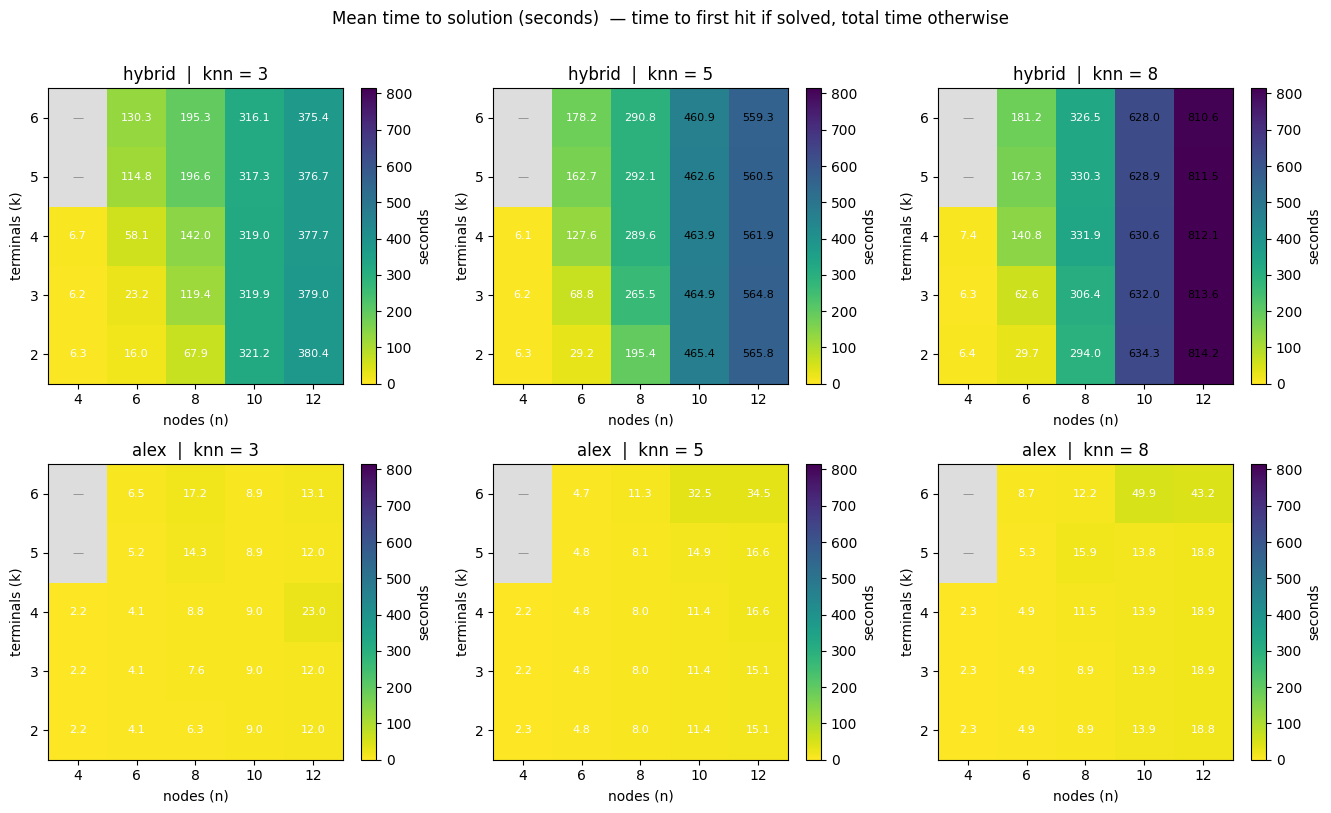

In [19]:
finite_tts = arr_tts[np.isfinite(arr_tts)]
vmax_tts   = float(np.nanmax(arr_tts)) if finite_tts.size else 1.0

fig5 = plot_metric(
    arr_tts,
    title="Mean time to solution (seconds)  — time to first hit if solved, total time otherwise",
    cbar_label="seconds",
    fmt="{:.1f}",
    cmap="viridis_r",      # less time = brighter = better
    vmin=0.0, vmax=vmax_tts,
    model_list=model_list,
    density_list=density_list,
    n_list=n_list, k_list=k_list,
    density_label=density_label,
)
plt.show()

## 6 · Head-to-head difference maps  (hybrid − alex)
Positive = hybrid is better, negative = alex is better.  Uses the same
per-combo averages already computed above.

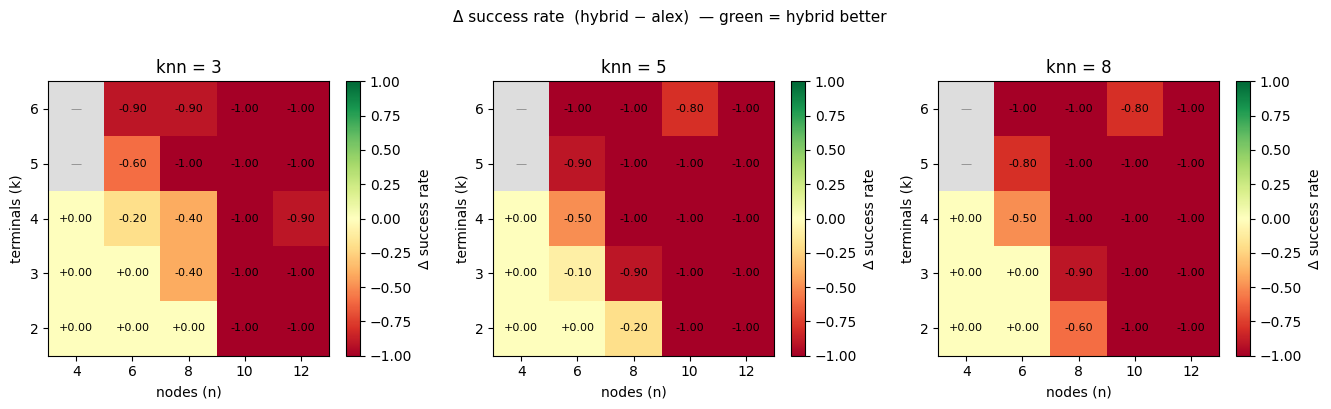

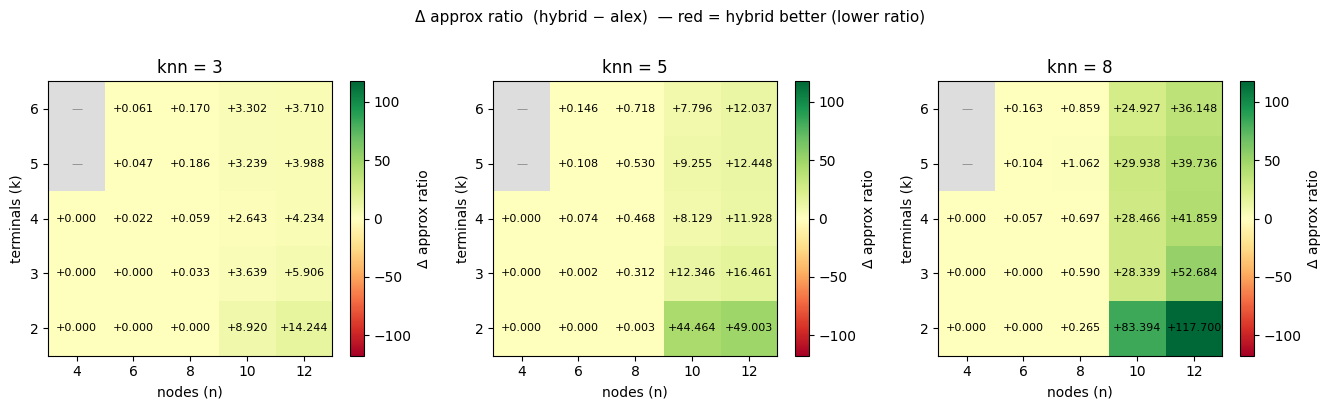

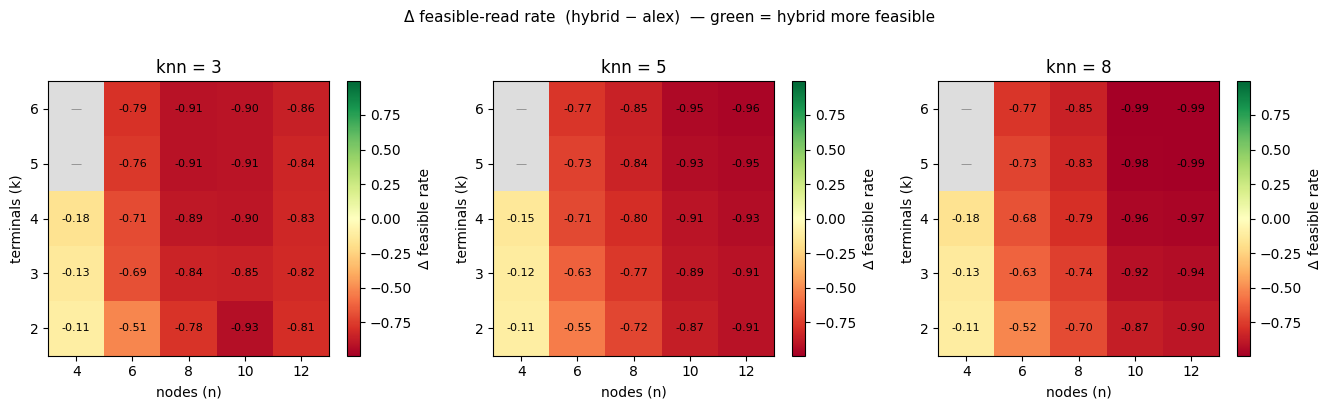

In [20]:
if len(model_list) == 2 and "hybrid" in model_list and "alex" in model_list:
    hi = model_list.index("hybrid")
    ai = model_list.index("alex")

    def _diff_heatmaps(arr_a, arr_b, *, title, cbar_label, fmt):
        """Plot (arr_a - arr_b) per density value."""
        diff = arr_a - arr_b          # shape (density, k, n)
        n_cols = len(density_list)
        fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.0), squeeze=False)
        vext = np.nanmax(np.abs(diff))
        if vext == 0 or np.isnan(vext):
            vext = 1e-3
        cmap_obj = plt.get_cmap("RdYlGn").copy()
        cmap_obj.set_bad(color="#dddddd")
        for di, d_val in enumerate(density_list):
            ax = axes[0][di]
            masked = np.ma.masked_invalid(diff[di])
            im = ax.imshow(masked, origin="lower", aspect="auto",
                           cmap=cmap_obj, vmin=-vext, vmax=vext)
            ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
            ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
            ax.set_xlabel("nodes (n)")
            ax.set_ylabel("terminals (k)")
            ax.set_title(f"{density_label} = {d_val}")
            for ki in range(len(k_list)):
                for ni in range(len(n_list)):
                    v = diff[di, ki, ni]
                    txt   = "—" if np.isnan(v) else fmt.format(v)
                    color = "#888888" if np.isnan(v) else "black"
                    ax.text(ni, ki, txt, ha="center", va="center",
                            color=color, fontsize=8)
            plt.colorbar(im, ax=ax, label=cbar_label)
        fig.suptitle(title, fontsize=11, y=1.01)
        fig.tight_layout()
        return fig

    # Success rate: positive = hybrid wins
    _diff_heatmaps(
        arr_success[hi], arr_success[ai],
        title="Δ success rate  (hybrid − alex)  — green = hybrid better",
        cbar_label="Δ success rate", fmt="{:+.2f}",
    )
    plt.show()

    # Approximation ratio: negative = hybrid wins (lower ratio is better)
    _diff_heatmaps(
        arr_ratio[hi], arr_ratio[ai],
        title="Δ approx ratio  (hybrid − alex)  — red = hybrid better (lower ratio)",
        cbar_label="Δ approx ratio", fmt="{:+.3f}",
    )
    plt.show()

    # Feasible-read rate: positive = hybrid wins
    _diff_heatmaps(
        arr_feasib[hi], arr_feasib[ai],
        title="Δ feasible-read rate  (hybrid − alex)  — green = hybrid more feasible",
        cbar_label="Δ feasible rate", fmt="{:+.2f}",
    )
    plt.show()
else:
    print("Diff maps require exactly the 'hybrid' and 'alex' models — skipping.")